 # PART 1: Auto Encoder

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
from torch.utils.data import TensorDataset, DataLoader

def draw_circle(radius, center_x=0.5, center_y=0.5, size=28):
    # draw a circle using coordinates for the center, and the radius
    circle = plt.Circle((center_x, center_y), radius, color='k', fill=False)
    fig, ax = plt.subplots(figsize=(1, 1))
    ax.add_patch(circle)
    ax.axis('off')
    buf = fig.canvas.print_to_buffer()
    plt.close()
    # converts matplotlib figure into PIL image, make it grayscale, and resize it
    return np.array(Image.frombuffer('RGBA', buf[1], buf[0]).convert('L').resize((int(size), int(size))))

def gen_circles(n, size=28):
    # generates random coordinates around (0.5, 0.5) as center points
    center_x = np.random.uniform(0.0, 0.03, size=n).reshape(-1, 1)+.5
    center_y = np.random.uniform(0.0, 0.03, size=n).reshape(-1, 1)+.5
    # generates random radius sizes between 0.03 and 0.47
    radius = np.random.uniform(0.03, 0.47, size=n).reshape(-1, 1)
    sizes = np.ones((n, 1))*size

    coords = np.concatenate([radius, center_x, center_y, sizes], axis=1)
    # generates circles using draw_circle function
    circles = np.apply_along_axis(func1d=lambda v: draw_circle(*v), axis=1, arr=coords)
    return circles, radius

np.random.seed(42)
# generates 1,000 circles
circles, radius = gen_circles(1000)

circles_ds = TensorDataset(torch.as_tensor(circles).unsqueeze(1).float()/255, torch.as_tensor(radius))
circles_dl = DataLoader(circles_ds, batch_size=32, shuffle=True, drop_last=True)

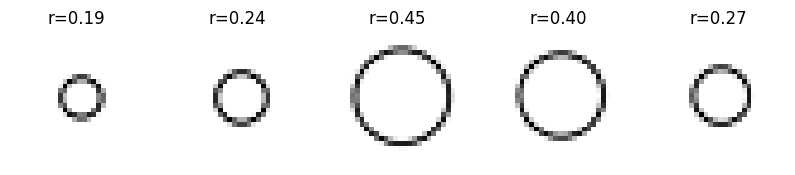

In [31]:
import matplotlib.pyplot as plt

images, labels = next(iter(circles_dl))
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f"r={labels[i].item():.2f}")
    plt.axis('off')
plt.show()


In [7]:
import torch.nn as nn

def set_seed(self, seed=42):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.manual_seed(seed)
    np.random.seed(seed)

class Encoder(nn.Module):
    def __init__(self, input_shape, z_size, base_model):
        super().__init__()
        self.input_shape = input_shape
        self.z_size = z_size
        self.base_model = base_model
        
        # appends the "lin_latent" linear layer to map from "output_size" 
        # given by the base model to desired size of the representation (z_size)
        output_size = self._get_output_size()
        self.lin_latent = nn.Linear(output_size, z_size)
        
    def _get_output_size(self):
        # builds a dummy batch containing one dummy tensor
        # full of zeroes with the same shape as the inputs
        device = next(self.base_model.parameters()).device.type
        dummy = torch.zeros(1, *self.input_shape, device=device)
        # sends the dummy batch through the base model to get 
        # the output size produced by it
        size = self.base_model(dummy).size(1)
        return size
        
    def forward(self, x):
        # forwards the input through the base model and then the "lin_latent" layer 
        # to get the representation (z)
        base_out = self.base_model(x)
        out = self.lin_latent(base_out)        
        return out

set_seed(13)

# we defined our representation (z) as a vector of size one
z_size = 1
# our images are 1@28x28
input_shape = (1, 28, 28) # (C, H, W)

base_model = nn.Sequential(
    # (C, H, W) -> C*H*W
    nn.Flatten(),
    # C*H*W -> 2048
    nn.Linear(np.prod(input_shape), 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
)

encoder = Encoder(input_shape, z_size, base_model)


In [11]:
decoder = nn.Sequential(
    # z_size -> 2048
    nn.Linear(z_size, 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
    # 2048 -> C*H*W
    nn.Linear(2048, np.prod(input_shape)),
    # C*H*W -> (C, H, W)
    nn.Unflatten(1, input_shape)
)

In [12]:
class AutoEncoder(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.enc = encoder
        self.dec = decoder
        
    def forward(self, x):
        # when encoder met decoder
        enc_out = self.enc(x)
        return self.dec(enc_out)
    
model_ae = AutoEncoder(encoder, decoder)


In [13]:
set_seed(13)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_ae.to(device)
loss_fn = nn.MSELoss()
optim = torch.optim.Adam(model_ae.parameters(), 0.0003)

num_epochs = 10

train_losses = []

for epoch in range(1, num_epochs+1):
    batch_losses = []
    for i, (x, _) in enumerate(circles_dl):
        model_ae.train()
        x = x.to(device)

        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model_ae(x)
        # Step 2 - Computes the loss
        loss = loss_fn(yhat, x) 
        # Step 3 - Computes gradients
        loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optim.step()
        optim.zero_grad()
        
        batch_losses.append(np.array([loss.data.item()]))

    # Average over batches
    train_losses.append(np.array(batch_losses).mean(axis=0))

    print(f'Epoch {epoch:03d} | Loss >> {train_losses[-1][0]:.4f}')

Epoch 001 | Loss >> 0.1388
Epoch 002 | Loss >> 0.0062
Epoch 003 | Loss >> 0.0049
Epoch 004 | Loss >> 0.0048
Epoch 005 | Loss >> 0.0048
Epoch 006 | Loss >> 0.0048
Epoch 007 | Loss >> 0.0048
Epoch 008 | Loss >> 0.0048
Epoch 009 | Loss >> 0.0047
Epoch 010 | Loss >> 0.0046


# Variational AutoEncoder

In [18]:
def forward(self, x):
    base_out = self.base_model(x)
        
    self.mu = self.lin_mu(base_out)
    self.log_var = self.lin_var(base_out)
    std = torch.exp(self.log_var/2)
                
    eps = torch.randn_like(self.mu)
    z = self.mu + eps * std
    return z

In [19]:
# from torch.distributions.normal.Normal

def sample(self, sample_shape=torch.Size()):
    shape = self._extended_shape(sample_shape)
    with torch.no_grad():
        return torch.normal(self.loc.expand(shape),
                            self.scale.expand(shape))

def rsample(self, sample_shape=torch.Size()):
    shape = self._extended_shape(sample_shape)
    eps = _standard_normal(shape, 
                           dtype=self.loc.dtype,
                           device=self.loc.device)
    return self.loc + eps * self.scale

In [20]:
def kl_div(mu, std):
    kl_div = -0.5*(1 + np.log(std**2) - mu**2 - std**2)
    return kl_div

In [21]:
class EncoderVar(nn.Module):
    def __init__(self, input_shape, z_size, base_model):
        super().__init__()
        self.z_size = z_size
        self.input_shape = input_shape
        self.base_model = base_model
        output_size = self.get_output_size()
        self.lin_mu = nn.Linear(output_size, z_size)
        self.lin_var = nn.Linear(output_size, z_size)
        
    def get_output_size(self):
        device = next(self.base_model.parameters()).device.type
        size = self.base_model(torch.zeros(1, *self.input_shape, device=device)).size(1)
        return size
    
    def kl_loss(self):
        kl_loss = -0.5*(1 + self.log_var - self.mu**2 - torch.exp(self.log_var))
        return kl_loss
        
    def forward(self, x):
        # the base model, same as the traditional AE
        base_out = self.base_model(x)
        
        # now the encoder produces means (mu) using the lin_mu output layer
        # and log variances (log_var) using the lin_var output layer
        # we compute the standard deviation (std) from the log variance
        self.mu = self.lin_mu(base_out)
        self.log_var = self.lin_var(base_out)
        std = torch.exp(self.log_var/2)
                
        # that's the internal random input (epsilon)
        eps = torch.randn_like(self.mu)
        # and that's the z vector
        z = self.mu + eps * std
        
        return z

In [22]:
set_seed(13)

base_model = nn.Sequential(
    # (C, H, W) -> C*H*W
    nn.Flatten(),
    # C*H*W -> 2048
    nn.Linear(np.prod(input_shape), 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
)

encoder_var = EncoderVar(input_shape, z_size, base_model)

decoder_var = nn.Sequential(
    # z_size -> 2048
    nn.Linear(z_size, 2048),
    nn.LeakyReLU(),
    # 2048 -> 2048
    nn.Linear(2048, 2048),
    nn.LeakyReLU(),
    # 2048 -> C*H*W
    nn.Linear(2048, np.prod(input_shape)),
    # C*H*W -> (C, H, W)
    nn.Unflatten(1, input_shape)
)

model_vae = AutoEncoder(encoder_var, decoder_var)

In [23]:
x, y = next(iter(circles_dl))
zs = encoder_var(x)
reconstructed = decoder_var(zs)

In [24]:
loss_fn_raw = nn.MSELoss(reduction='none')
raw_mse = loss_fn_raw(reconstructed, x)
raw_mse.shape

torch.Size([32, 1, 28, 28])

In [25]:
raw_mse.sum(), nn.MSELoss(reduction='sum')(reconstructed, x)

(tensor(24377.3906, grad_fn=<SumBackward0>),
 tensor(24377.3906, grad_fn=<MseLossBackward0>))

In [26]:
sum_over_pixels = raw_mse.sum(dim=[1, 2, 3])
sum_over_pixels.mean()

tensor(761.7935, grad_fn=<MeanBackward0>)

In [27]:
raw_kl = encoder_var.kl_loss()
raw_kl.shape

torch.Size([32, 1])

In [28]:
for raw, d in zip([raw_mse, raw_kl], [[1, 2, 3], 1]):
    print(f'{raw.mean(dim=d).mean(dim=0).item():.4f}, {raw.mean(dim=d).sum(dim=0).item():.4f}, '
          f'{raw.sum(dim=d).mean(dim=0).item():.4f}, {raw.sum(dim=d).sum(dim=0).item():.4f}')

0.9717, 31.0936, 761.7935, 24377.3906
0.0062, 0.1998, 0.0062, 0.1998


In [29]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_vae.to(device)
loss_fn = nn.MSELoss(reduction='none')
optim = torch.optim.Adam(model_vae.parameters(), 0.0003)

num_epochs = 30

train_losses = []

reconstruction_loss_factor = 1

for epoch in range(1, num_epochs+1):
    batch_losses = []
    for i, (x, _) in enumerate(circles_dl):
        model_vae.train()
        x = x.to(device)

        # Step 1 - Computes our model's predicted output - forward pass
        yhat = model_vae(x)

        # Step 2 - Computes the loss
        # reduce (sum) over pixels (dim=[1, 2, 3])
        # and then reduce (sum) over batch (dim=0)
        loss = loss_fn(yhat, x).sum(dim=[1, 2, 3]).sum(dim=0)
        # reduce (sum) over z (dim=1)
        # and then reduce (sum) over batch (dim=0)
        kl_loss = model_vae.enc.kl_loss().sum(dim=1).sum(dim=0)
        # we're adding the KL loss to the original MSE loss
        total_loss = reconstruction_loss_factor * loss + kl_loss

        # Step 3 - Computes gradients
        total_loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        optim.step()
        optim.zero_grad()
        
        batch_losses.append(np.array([total_loss.data.item(), loss.data.item(), kl_loss.data.item()]))

    # Average over batches
    train_losses.append(np.array(batch_losses).mean(axis=0))

    print(f'Epoch {epoch:03d} | Loss >> {train_losses[-1][0]:.4f}/{train_losses[-1][1]:.4f}/{train_losses[-1][2]:.4f}')

Epoch 001 | Loss >> 2091.0370/2026.1968/64.8402
Epoch 002 | Loss >> 179.0802/142.0729/37.0073
Epoch 003 | Loss >> 149.9079/130.6101/19.2978
Epoch 004 | Loss >> 138.4540/127.9288/10.5252
Epoch 005 | Loss >> 132.4553/126.9412/5.5141
Epoch 006 | Loss >> 138.2764/133.9197/4.3566
Epoch 007 | Loss >> 136.4070/132.5028/3.9041
Epoch 008 | Loss >> 134.7296/131.0996/3.6300
Epoch 009 | Loss >> 129.3563/128.1685/1.1878
Epoch 010 | Loss >> 136.5038/134.4967/2.0071
Epoch 011 | Loss >> 136.5470/133.8538/2.6932
Epoch 012 | Loss >> 130.1400/128.9647/1.1753
Epoch 013 | Loss >> 132.5746/130.9875/1.5871
Epoch 014 | Loss >> 130.8196/129.7229/1.0967
Epoch 015 | Loss >> 129.4555/128.8504/0.6051
Epoch 016 | Loss >> 129.2993/128.4933/0.8060
Epoch 017 | Loss >> 130.1003/129.6531/0.4472
Epoch 018 | Loss >> 127.7388/127.2881/0.4507
Epoch 019 | Loss >> 131.0609/130.6493/0.4116
Epoch 020 | Loss >> 130.3081/129.8251/0.4830
Epoch 021 | Loss >> 135.5521/133.1937/2.3584
Epoch 022 | Loss >> 128.5452/128.1899/0.3554
Epoc